In [5]:
import pandas as pd

In [6]:
# Load the dataset
df = pd.read_csv('Titanic-Dataset.csv')

In [7]:
# Look at the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Check how many missing values are in each column
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
# Fill missing Age with median
df['Age'] = df['Age'].fillna(df['Age'].median())

In [10]:
# Fill missing Embarked with the mode (most common value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [11]:
# Drop Cabin because it's mostly empty
df = df.drop(columns=['Cabin'])

In [12]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [13]:
# Drop Name, Ticket, and PassengerId
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])

In [14]:
# Convert categorical text columns into numbers
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Look at our clean, numeric dataset
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [15]:
# Separate features and target
X = df.drop(columns=['Survived'])
y = df['Survived']

In [16]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 712
Testing samples: 179


In [17]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model
model = RandomForestClassifier(random_state=42)

# 2. Train the model using the training data
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [18]:
from sklearn.metrics import accuracy_score

# Use the trained model to predict the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"🎉 Your Model Accuracy is: {accuracy * 100:.2f}%")

🎉 Your Model Accuracy is: 82.12%


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

# Print detailed classification report
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))


Detailed Performance Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



/tmp/ipykernel_5262/1159970841.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


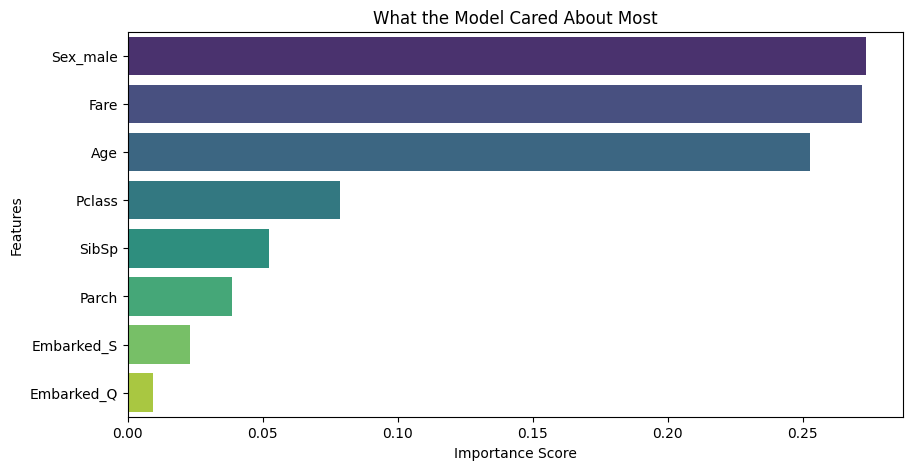

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt  # <-- This fixes the plt error!
import seaborn as sns            # <-- This ensures sns works too!

# Get feature importances from our model
importances = model.feature_importances_
features = X.columns

# Create a dataframe for easy plotting
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot it
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('What the Model Cared About Most')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()